# Random Forest — Predicting Alzheimer's Diagnosis from a CSF Biomarker

This notebook trains **one** Random Forest model to predict a patient's diagnosis (`DX`) from a single biomarker ratio, **PTAU/ABETA**, then produces every metric and every figure from that single fitted model.

| Item | Value |
|------|-------|
| Problem type | Multi-class classification |
| Feature (X) | `PTAU/ABETA` |
| Target (Y)  | `DX` → CN=0, MCI=1, DEM=3 |
| Split | 70% train / 30% test, stratified on the label |

**Input file:** `ADNI_CSF_biomarkers_processed.csv` (produced by `process_biomarkers.py`).

> Run order matters: execute the cells top to bottom. Sections 4–7 all reuse the single model fit in section 4.

## 0. Imports & configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# Show plots inline in the notebook
%matplotlib inline

# ---------------------------------------------------------------- config
DATA_PATH = "ADNI_CSF_biomarkers_processed.csv"
RANDOM_STATE = 42
ORDER = ["CN", "MCI", "DEM"]
COL = {"CN": "#2EC4A0", "MCI": "#F5A623", "DEM": "#6C5CE7"}  # class colours
plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titleweight": "bold",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

## Helper: augmented confusion matrix

Draws a confusion matrix with a **recall** column, an **F1** column, and a **precision** row (used for Fig 7).

In [ ]:
def plot_augmented_confusion_matrix(cm, classes, outfile, title=None):
    """Confusion matrix with a recall column, F1 column, and precision row.
    Margins are plain text (no tiles); count cells use one charcoal text colour
    on a teal ramp kept light enough to stay legible on every cell."""
    cm = np.asarray(cm)
    n = len(classes)
    diag = np.diag(cm)
    recall = diag / cm.sum(axis=1)
    precision = diag / cm.sum(axis=0)
    f1 = 2 * precision * recall / (precision + recall)
    accuracy = diag.sum() / cm.sum()
    f1_macro = f1.mean()
    f1_weighted = np.average(f1, weights=cm.sum(axis=1))

    ramp = LinearSegmentedColormap.from_list("teal", ["#F3FBF9", "#2EC4A0"])
    TEXT = "#1A1A1A"  # one text colour for every count cell
    cmax = cm.max()

    ncol, nrow = n + 2, n + 1  # cols: classes + Recall + F1 ; rows: classes + Precision
    fig, ax = plt.subplots(figsize=(1.4 * ncol + 1.4, 1.2 * nrow + 1.4))

    norm = 0.10 + 0.90 * cm / cmax
    ax.imshow(
        norm,
        cmap=ramp,
        vmin=0,
        vmax=1,
        aspect="auto",
        extent=[0, n, nrow - n, nrow],
        origin="upper",
        zorder=0,
    )
    ax.add_patch(
        Rectangle((0, nrow - n), n, n, fill=False, edgecolor="#333", lw=1.2, zorder=3)
    )
    for i in range(n):  # count values, one text colour
        for j in range(n):
            ax.text(
                j + 0.5,
                nrow - 0.5 - i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color=TEXT,
                fontsize=17,
                zorder=4,
                fontweight="bold" if i == j else "normal",
            )

    for i in range(n):  # recall + F1 per class row (plain text)
        ax.text(n + 0.5, nrow - 0.5 - i, f"{recall[i]:.2f}", ha="center", va="center", fontsize=14)
        ax.text(n + 1.5, nrow - 0.5 - i, f"{f1[i]:.2f}", ha="center", va="center", fontsize=14)
    for j in range(n):  # precision per class column (plain text)
        ax.text(j + 0.5, 0.5, f"{precision[j]:.2f}", ha="center", va="center", fontsize=14)

    for j, lab in enumerate(classes):  # headers
        ax.text(j + 0.5, nrow + 0.18, lab, ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.text(n + 0.5, nrow + 0.18, "Recall", ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.text(n + 1.5, nrow + 0.18, "F1", ha="center", va="bottom", fontsize=13, fontweight="bold")
    for i, lab in enumerate(classes):
        ax.text(-0.18, nrow - 0.5 - i, lab, ha="right", va="center", fontsize=13, fontweight="bold")
    ax.text(-0.18, 0.5, "Precision", ha="right", va="center", fontsize=13, fontweight="bold")

    ax.text(n / 2, nrow + 0.55, "Predicted", ha="center", fontsize=13.5, fontweight="bold", color="#555")
    ax.text(
        -0.95,
        nrow - 0.5 - (n - 1) / 2,
        "Actual",
        ha="center",
        va="center",
        rotation=90,
        fontsize=13.5,
        fontweight="bold",
        color="#555",
    )
    ax.text(
        ncol / 2,
        -0.55,
        f"Accuracy = {accuracy:.3f}    |    Macro-F1 = {f1_macro:.3f}"
        f"    |    Weighted-F1 = {f1_weighted:.3f}",
        ha="center",
        fontsize=12.5,
        color="#333",
    )

    if title:
        ax.text(ncol / 2, nrow + 1.15, title, ha="center", va="bottom", fontsize=16, fontweight="bold", color="#222")

    ax.set_xlim(-1.5, ncol + 0.15)
    ax.set_ylim(-0.9, nrow + (1.8 if title else 1.2))
    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load + clean

Drop rows with no label or no feature value (a handful lack `DX`; 2 lack the ratio).

In [3]:
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)

df = df.dropna(subset=["DX", "PTAU/ABETA"]).reset_index(drop=True)
print("Usable rows after cleaning:", len(df))
df.head()

Raw shape: (2000, 8)
Usable rows after cleaning: 1812


,RID,VISCODE,DRAWDTE,ABETA,PTAU,PTAU/ABETA,DX,Source
0,2,bl,9/8/2005,27.92,0.199,0.044601,CN,Plasma
1,3,bl,9/12/2005,131.00,20.400,0.066507,DEM,CSF
2,4,bl,11/22/2005,256.00,12.900,0.009418,MCI,CSF
3,5,bl,9/7/2005,116.00,67.200,0.296080,CN,CSF
4,8,bl,9/19/2005,268.00,29.000,0.040754,CN,CSF


## 2. Encode target + define X / Y

`CN=0, MCI=1, DEM=3` (the gap at 2 is harmless for a tree model).

In [4]:
dx_map = {"CN": 0, "MCI": 1, "DEM": 3}
inv = {v: k for k, v in dx_map.items()}
df["y"] = df["DX"].map(dx_map)

X = df[["PTAU/ABETA"]].values  # 2-D: (n_samples, 1 feature)
y = df["y"].values
labels = [dx_map[c] for c in ORDER]  # [0, 1, 3]

## 3. Train / test split  (70/30, stratified — DEM is a ~16% minority)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)}   Test: {len(X_test)}")

Train: 1268   Test: 544


## 4. Train the model  (once — everything below reuses this fit)

In [6]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
).fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)  # columns follow clf.classes_
y_test_bin = label_binarize(y_test, classes=labels)

## 5. Metrics

In [7]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weight = f1_score(y_test, y_pred, average="weighted")
auc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
auc_weight = roc_auc_score(y_test_bin, y_proba, average="weighted", multi_class="ovr")

print("=" * 55)
print(f"Accuracy        : {acc:.3f}")
print(f"F1 (macro)      : {f1_macro:.3f}")
print(f"F1 (weighted)   : {f1_weight:.3f}")
print(f"AUC OVR (macro) : {auc_macro:.3f}")
print(f"AUC OVR (weight): {auc_weight:.3f}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, labels=labels, target_names=ORDER))

cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=ORDER, columns=ORDER).to_string())

Accuracy        : 0.485
F1 (macro)      : 0.448
F1 (weighted)   : 0.438
AUC OVR (macro) : 0.680
AUC OVR (weight): 0.648

Per-class report:
              precision    recall  f1-score   support

          CN       0.59      0.77      0.67       215
         MCI       0.53      0.15      0.23       243
         DEM       0.32      0.73      0.45        86

    accuracy                           0.49       544
   macro avg       0.48      0.55      0.45       544
weighted avg       0.52      0.49      0.44       544

Confusion matrix (rows = true, cols = predicted):
      CN  MCI  DEM
CN   165   18   32
MCI  105   36  102
DEM    9   14   63


## 6. Figures  (all drawn from the single fitted model above)

### Fig 1 — class distribution (motivates the stratified split)

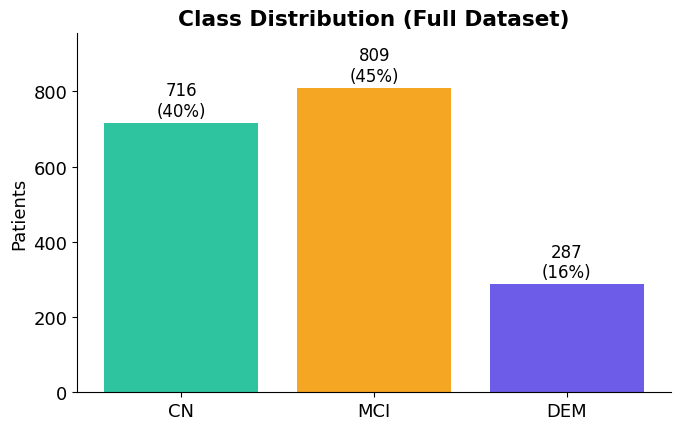

In [8]:
counts = df["DX"].value_counts().reindex(ORDER)
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(ORDER, counts.values, color=[COL[c] for c in ORDER])
for b, v in zip(bars, counts.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 8,
        f"{v}\n({v/counts.sum()*100:.0f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
    )
ax.set_title("Class Distribution (Full Dataset)")
ax.set_ylabel("Patients")
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("fig1_class_distribution.png", dpi=150)
plt.show()

### Fig 2 — confusion matrix

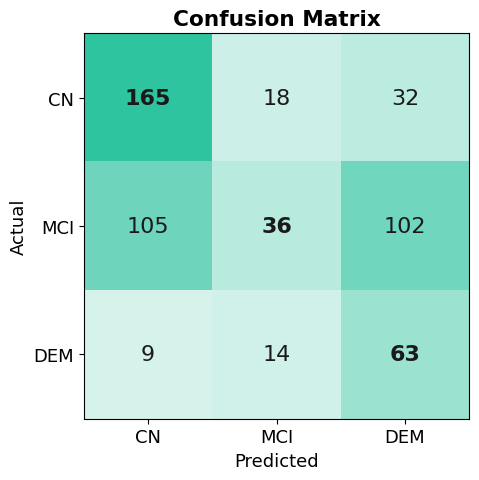

In [9]:
ramp = LinearSegmentedColormap.from_list("teal", ["#F3FBF9", "#2EC4A0"])
norm = 0.10 + 0.90 * cm / cm.max()
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.imshow(norm, cmap=ramp, vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16,
            color="#1A1A1A",
            fontweight="bold" if i == j else "normal",
        )
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(ORDER)
ax.set_yticklabels(ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
fig.tight_layout()
fig.savefig("fig2_confusion_matrix.png", dpi=150)
plt.show()

### Fig 3 — actual vs. predicted counts

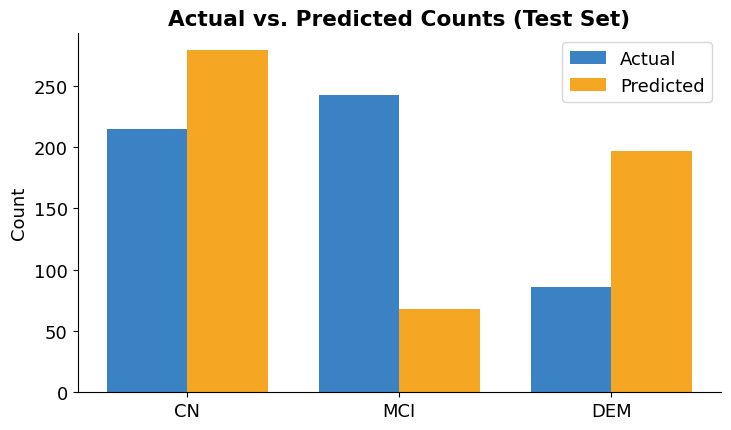

In [10]:
actual = pd.Series(y_test).map(inv).value_counts().reindex(ORDER)
pred = pd.Series(y_pred).map(inv).value_counts().reindex(ORDER).fillna(0)
x = np.arange(3)
w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(x - w / 2, actual.values, w, label="Actual", color="#3B82C4")
ax.bar(x + w / 2, pred.values, w, label="Predicted", color="#F5A623")
ax.set_xticks(x)
ax.set_xticklabels(ORDER)
ax.set_ylabel("Count")
ax.set_title("Actual vs. Predicted Counts (Test Set)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("fig3_actual_vs_predicted.png", dpi=150)
plt.show()

### Fig 4 — per-class precision / recall / F1

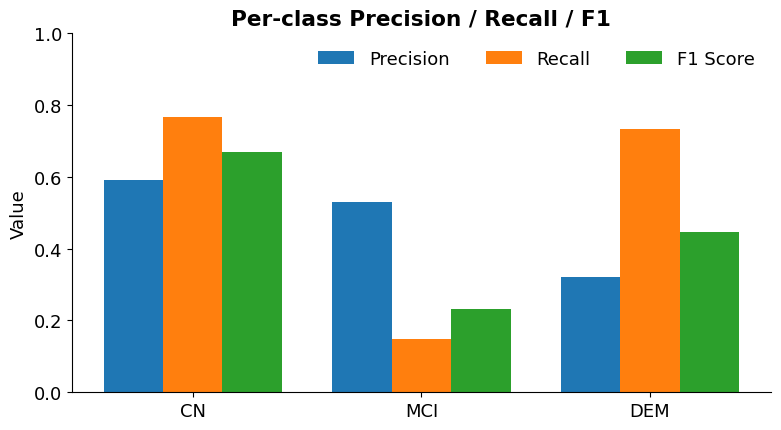

In [11]:
rep = classification_report(
    y_test, y_pred, labels=labels, target_names=ORDER, output_dict=True
)
metrics = [("precision", "Precision"), ("recall", "Recall"), ("f1-score", "F1 Score")]
x = np.arange(3)
w = 0.26
fig, ax = plt.subplots(figsize=(8, 4.5))
for k, (key, label) in enumerate(metrics):  # key reads the report; label is shown
    ax.bar(x + (k - 1) * w, [rep[c][key] for c in ORDER], w, label=label)
ax.set_xticks(x)
ax.set_xticklabels(ORDER)
ax.set_ylim(0, 1)
ax.set_ylabel("Value")
ax.set_title("Per-class Precision / Recall / F1")
ax.legend(ncol=3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("fig4_per_class_metrics.png", dpi=150)
plt.show()

### Fig 5 — ROC curves (one-vs-rest)

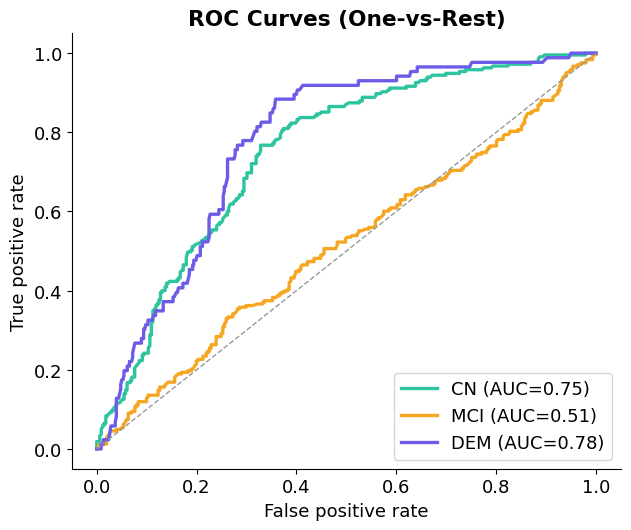

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for i, c in enumerate(ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, color=COL[c], lw=2.4, label=f"{c} (AUC={auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], "--", color="#999", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("fig5_roc_curves.png", dpi=150)
plt.show()

### Fig 6 — feature value by diagnosis (why MCI is hard)

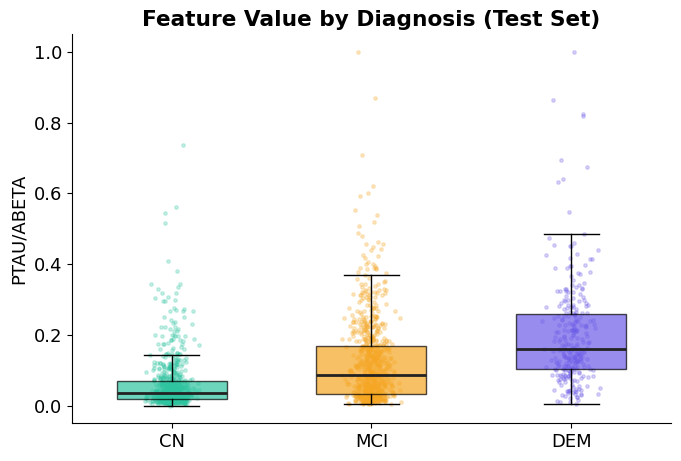

In [13]:
data = [df.loc[df["DX"] == c, "PTAU/ABETA"].values for c in ORDER]
fig, ax = plt.subplots(figsize=(7, 4.8))
bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False)
for patch, c in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COL[c])
    patch.set_alpha(0.7)
for med in bp["medians"]:
    med.set_color("#222")
    med.set_linewidth(2)
for i, c in enumerate(ORDER):
    ax.scatter(
        np.random.normal(i + 1, 0.05, len(data[i])),
        data[i],
        s=6,
        color=COL[c],
        alpha=0.25,
    )
ax.set_xticklabels(ORDER)
ax.set_ylabel("PTAU/ABETA")
ax.set_title("Feature Value by Diagnosis (Test Set)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("fig6_feature_by_diagnosis.png", dpi=150)
plt.show()

### Fig 7 — augmented confusion matrix (recall col, F1 col, precision row)

Uses the same `cm` computed in section 5 → numbers always match the report.

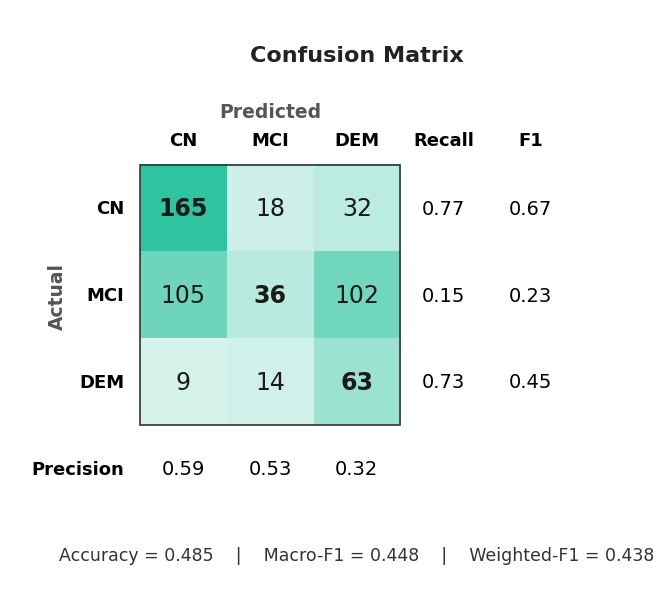

Saved 7 figures: fig1..fig7 (.png)


In [14]:
plot_augmented_confusion_matrix(
    cm, ORDER, "fig7_confusion_matrix_augmented.png", title="Confusion Matrix"
)
print("Saved 7 figures: fig1..fig7 (.png)")